In [134]:
import numpy as np
import pandas as pd
from scipy import signal
import matplotlib.pyplot as plt

In [135]:
# toy dataset

data = pd.read_csv('./data/test.tsv', sep='\t')
data.dropna(inplace=True)
data.sort_values(by='time', inplace=True)
data.reset_index(drop=True, inplace=True)

In [136]:
data.columns

Index(['identifier', 'sex', 'age', 'time', 'CRP_bl', 'FERR_bl', 'IRON_bl',
       'TRANSFS_bl', 'UIBC_bl', 'TRANSF_bl', 'HEP_bl', 'WBC_10_9_L_bl',
       'RBC_10_12_L_bl', 'HGB_g_dL_bl', 'HCT_PCT_bl', 'MCV_fL_bl', 'MCH_pg_bl',
       'MCHC_g_dL_bl', 'PLT_10_9_L_bl', 'RDW_SD_fL_bl', 'RDW_CV_PCT_bl',
       'PDW_fL_bl', 'MPV_fL_bl', 'P_LCR_PCT_bl', 'PCT_PCT_bl',
       'NEUT_10_9_L_bl', 'LYMPH_10_9_L_bl', 'MONO_10_9_L_bl', 'EO_10_9_L_bl',
       'BASO_10_9_L_bl', 'NEUT_PCT_bl', 'LYMPH_PCT_bl', 'MONO_PCT_bl',
       'EO_PCT_bl', 'BASO_PCT_bl', 'IG_10_9_L_bl', 'IG_PCT_bl', 'RET_PCT_bl',
       'RET_10_6_uL_bl', 'IRF_PCT_bl', 'LFR_PCT_bl', 'MFR_PCT_bl',
       'HFR_PCT_bl', 'RET_He_pg_bl', 'IPF_bl', 'PLT_I_10_9_L_bl',
       'MicroR_PCT_bl', 'MacroR_PCT_bl', 'TNC_10_9_L_bl', 'WBC_N_10_9_L_bl',
       'TNC_N_10_9_L_bl', 'BA_N_10_9_L_bl', 'BA_N_PCT_bl', 'WBC_D_10_9_L_bl',
       'TNC_D_10_9_L_bl', 'NEUTx_10_9_L_bl', 'NEUTx_PCT_bl', 'LYMP_10_9_L_bl',
       'LYMP_PCT_bl', 'BA_D_10_9_L_bl', 'BA

In [148]:
response = 'MONO_PCT_bl'
y = data[response].values

# transform into an average smoothing curve

N = 100
eps = 0.25
time_grid = np.linspace(data['time'].min() + eps, data['time'].max() - eps, N)
y_smooth = [np.mean(y[(data['time'] >= t - eps) & (data['time'] <= t + eps)]) for t in time_grid]

# center
y_smooth_centered = y_smooth - np.mean(y_smooth)
# detrend
y_smooth_detrended = signal.detrend(y_smooth_centered)

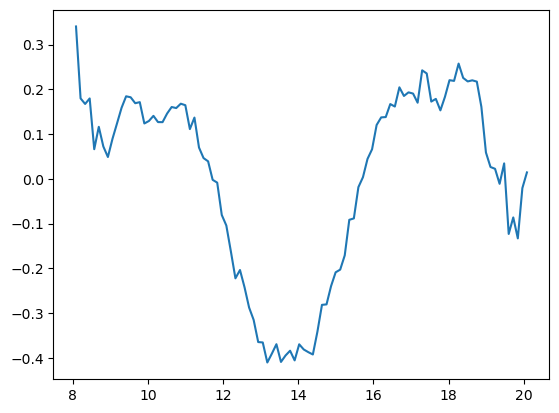

In [149]:
plt.plot(time_grid, y_smooth_detrended)
plt.show()

In [111]:
def calculate_spectrum(data, sampling_rate):
    """
    Calculates the frequency spectrum (periodogram) of a signal.
    
    Args:
        data (array_like): The time-resolved numeric values.
        sampling_rate (float): The number of samples per second (Hz).
        
    Returns:
        f: Array of sample frequencies.
        Pxx: Power spectral density of the signal.
    """
    f, Pxx = signal.periodogram(data, sampling_rate)
    return f, Pxx


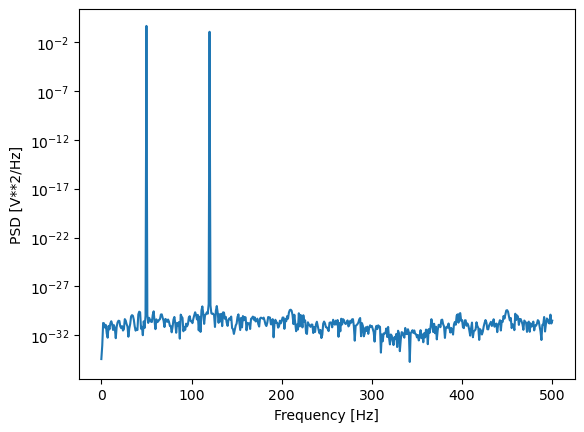

In [112]:
# Example Usage:

fs = 1000  # Sampling frequency (1000 Hz)
t = np.arange(0, 1.0, 1/fs) # 1 second time vector
# Create a signal with 50Hz and 120Hz components
x = np.sin(2*np.pi*50*t) + 0.5*np.sin(2*np.pi*120*t)

f, Pxx = calculate_spectrum(x, fs)

plt.semilogy(f, Pxx)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.show()


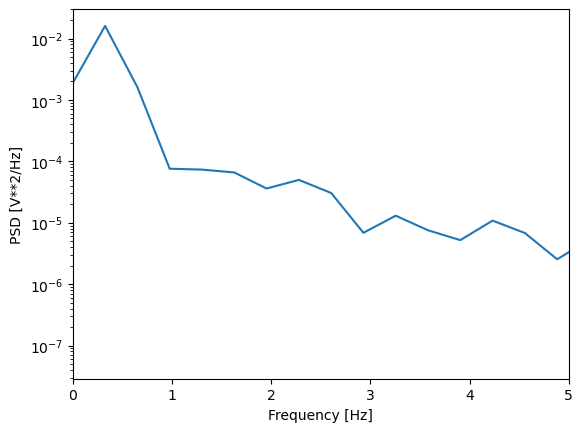

In [124]:
# Example Usage:
fs = len(y_smooth_detrended) / 12  # Sampling frequency (Hz)

# f, Pxx = calculate_spectrum(y_smooth_detrended, fs)
f, Pxx = signal.welch(y_smooth_detrended, fs)

plt.semilogy(f, Pxx)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.xlim(0,5)
plt.show()

In [125]:
f[np.argmax(Pxx)]

np.float64(0.3255208333333333)

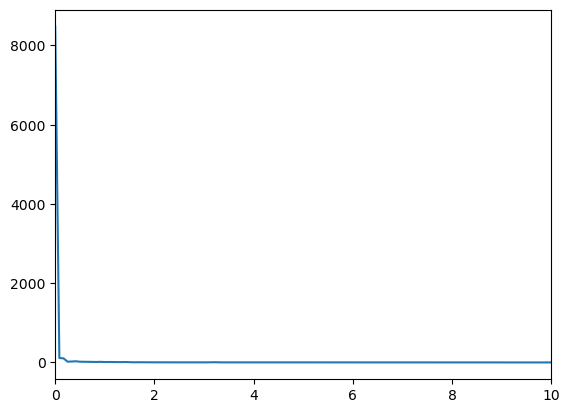

In [94]:
def manual_fft(data, fs):
    n = len(data)
    # Compute the FFT
    fft_values = np.fft.rfft(data)
    # Get the frequencies associated with the components
    freqs = np.fft.rfftfreq(n, d=1/fs)
    # Calculate magnitude (power)
    magnitude = np.abs(fft_values)
    return freqs, magnitude

fs = len(y_smooth) / 12  # Sampling frequency (Hz)
freqs, magnitude = manual_fft(y_smooth, fs)
plt.plot(freqs, magnitude)
plt.xlim(0,10)
plt.show()

In [139]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_lomb_scargle(time_array, signal_array):
    # 1. Preprocessing: Lomb-Scargle expects a zero-centered signal
    signal_centered = signal_array - np.mean(signal_array)
    
    # 2. Define the frequency range to scan
    # It's common to look from 1/total_time up to a "pseudo-Nyquist" limit
    total_time = time_array.max() - time_array.min()
    min_dist = np.min(np.diff(time_array)) # Smallest gap between points
    
    # Define frequencies (in Hz)
    freqs = np.linspace(0.01, 1 / (2 * min_dist), 1000)
    
    # 3. Convert Hz to angular frequencies (radians/sec) for Scipy
    angular_freqs = 2 * np.pi * freqs
    
    # 4. Calculate the periodogram
    pgram = signal.lombscargle(time_array, signal_centered, angular_freqs, normalize=True)
    
    # 5. Plotting
    plt.figure(figsize=(10, 5))
    plt.plot(freqs, pgram)
    plt.title('Lomb-Scargle Periodogram')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Normalized Power')
    plt.grid(True)
    plt.xlim(0,1)
    plt.show()

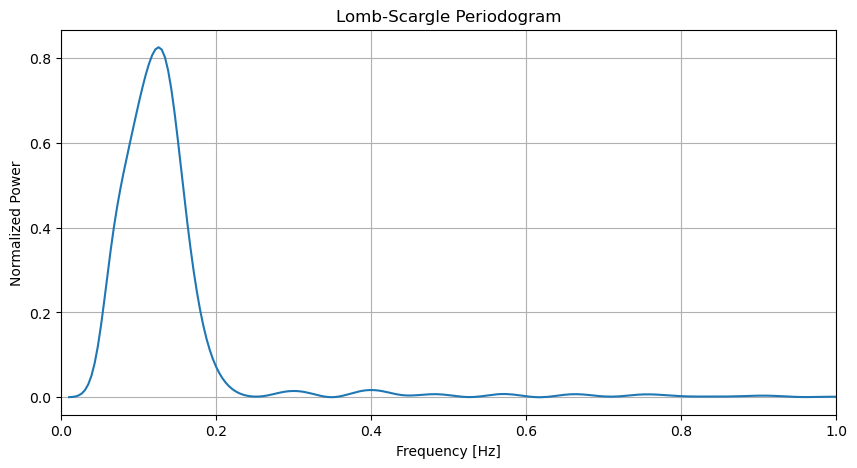

In [150]:
# option 1
plot_lomb_scargle(time_grid, y_smooth_detrended)

In [182]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

def plot_lomb_scargle_with_peaks(time_array, signal_array):
    # 1. Preprocessing
    signal_centered = signal_array - np.mean(signal_array)
    
    # 2. Define Frequency Range (Hz)
    total_time = time_array.max() - time_array.min()
    min_dist = np.min(np.diff(time_array))
    freqs = np.linspace(0.01, 1, 1000)
    angular_freqs = 2 * np.pi * freqs
    
    # 3. Calculate Periodogram
    pgram = signal.lombscargle(time_array, signal_centered, angular_freqs, normalize=True)
    
    # 4. Find Peaks
    # 'height' filters out low-power noise. 
    # Adjust 0.1 based on how clean your signal is.
    peak_indices, properties = signal.find_peaks(pgram, height=0.1, distance=10)
    
    peak_freqs = freqs[peak_indices]
    peak_powers = pgram[peak_indices]
    
    # 5. Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(freqs, pgram, label='Lomb-Scargle Power', color='black', alpha=0.7)
    
    # Highlight Peaks
    plt.plot(peak_freqs, peak_powers, "x", color='red', label='Detected Peaks')
    
    # Annotate the peaks with their frequency value
    for i, f in enumerate(peak_freqs):
        plt.annotate(f"{1/f:.2f}hours", (f, peak_powers[i]), textcoords="offset points", 
                     xytext=(30,0), ha='center', fontsize=9, color='red')

    plt.title('Lomb-Scargle Periodogram with Peak Detection')
    plt.xlabel('Frequency [1/hours]')
    plt.ylabel('Normalized Power')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    return peak_freqs, peak_powers

In [184]:
data.columns

Index(['identifier', 'sex', 'age', 'time', 'CRP_bl', 'FERR_bl', 'IRON_bl',
       'TRANSFS_bl', 'UIBC_bl', 'TRANSF_bl', 'HEP_bl', 'WBC_10_9_L_bl',
       'RBC_10_12_L_bl', 'HGB_g_dL_bl', 'HCT_PCT_bl', 'MCV_fL_bl', 'MCH_pg_bl',
       'MCHC_g_dL_bl', 'PLT_10_9_L_bl', 'RDW_SD_fL_bl', 'RDW_CV_PCT_bl',
       'PDW_fL_bl', 'MPV_fL_bl', 'P_LCR_PCT_bl', 'PCT_PCT_bl',
       'NEUT_10_9_L_bl', 'LYMPH_10_9_L_bl', 'MONO_10_9_L_bl', 'EO_10_9_L_bl',
       'BASO_10_9_L_bl', 'NEUT_PCT_bl', 'LYMPH_PCT_bl', 'MONO_PCT_bl',
       'EO_PCT_bl', 'BASO_PCT_bl', 'IG_10_9_L_bl', 'IG_PCT_bl', 'RET_PCT_bl',
       'RET_10_6_uL_bl', 'IRF_PCT_bl', 'LFR_PCT_bl', 'MFR_PCT_bl',
       'HFR_PCT_bl', 'RET_He_pg_bl', 'IPF_bl', 'PLT_I_10_9_L_bl',
       'MicroR_PCT_bl', 'MacroR_PCT_bl', 'TNC_10_9_L_bl', 'WBC_N_10_9_L_bl',
       'TNC_N_10_9_L_bl', 'BA_N_10_9_L_bl', 'BA_N_PCT_bl', 'WBC_D_10_9_L_bl',
       'TNC_D_10_9_L_bl', 'NEUTx_10_9_L_bl', 'NEUTx_PCT_bl', 'LYMP_10_9_L_bl',
       'LYMP_PCT_bl', 'BA_D_10_9_L_bl', 'BA

In [205]:
response = 'LYMP_PCT_bl'
y = data[response].values

# transform into an average smoothing curve

N = 100
eps = 0.25
time_grid = np.linspace(data['time'].min() + eps, data['time'].max() - eps, N)
y_smooth = [np.mean(y[(data['time'] >= t - eps) & (data['time'] <= t + eps)]) for t in time_grid]

# center
y_smooth_centered = y_smooth - np.mean(y_smooth)
# detrend
y_smooth_detrended = signal.detrend(y_smooth_centered)

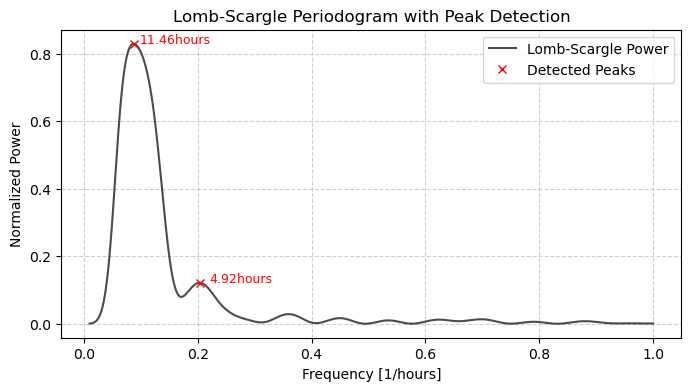

Detected peak frequencies: [0.0872973  0.20324324]


In [206]:
found_freqs, _ = plot_lomb_scargle_with_peaks(time_grid, y_smooth_detrended)
print(f"Detected peak frequencies: {found_freqs}")